In [1]:
from sklearn.datasets import fetch_california_housing

import numpy as np
import pandas as pd
import seaborn as sns   
import matplotlib.pyplot as plt 


In [4]:
housing= fetch_california_housing()
dataset=pd.DataFrame(housing.data,columns=housing.feature_names)

In [5]:
dataset['Price']=housing.target

In [6]:
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [7]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [8]:
dataset.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [9]:
dataset.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

VISUALIZATIONS :  USING HISTOGRAMS ,SUBPLOTS AND CORRELATION METRIXS 

Text(0.5, 1.0, 'AveRooms(raw)')

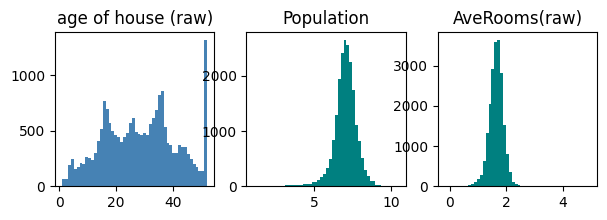

In [ ]:
plt.figure(figsize=(7, 2))

plt.subplot(1, 3, 1)
plt.hist(dataset['HouseAge'], bins=50, color='steelblue')
plt.title('age of house (raw)')


plt.subplot(1, 3, 2)
plt.hist(np.log(dataset['Population']), bins=50, color='teal')
plt.title('Population')

plt.subplot(1, 3, 3)
plt.hist(np.log(dataset['AveRooms']), bins=50, color='teal')
plt.title("AveRooms(raw)")

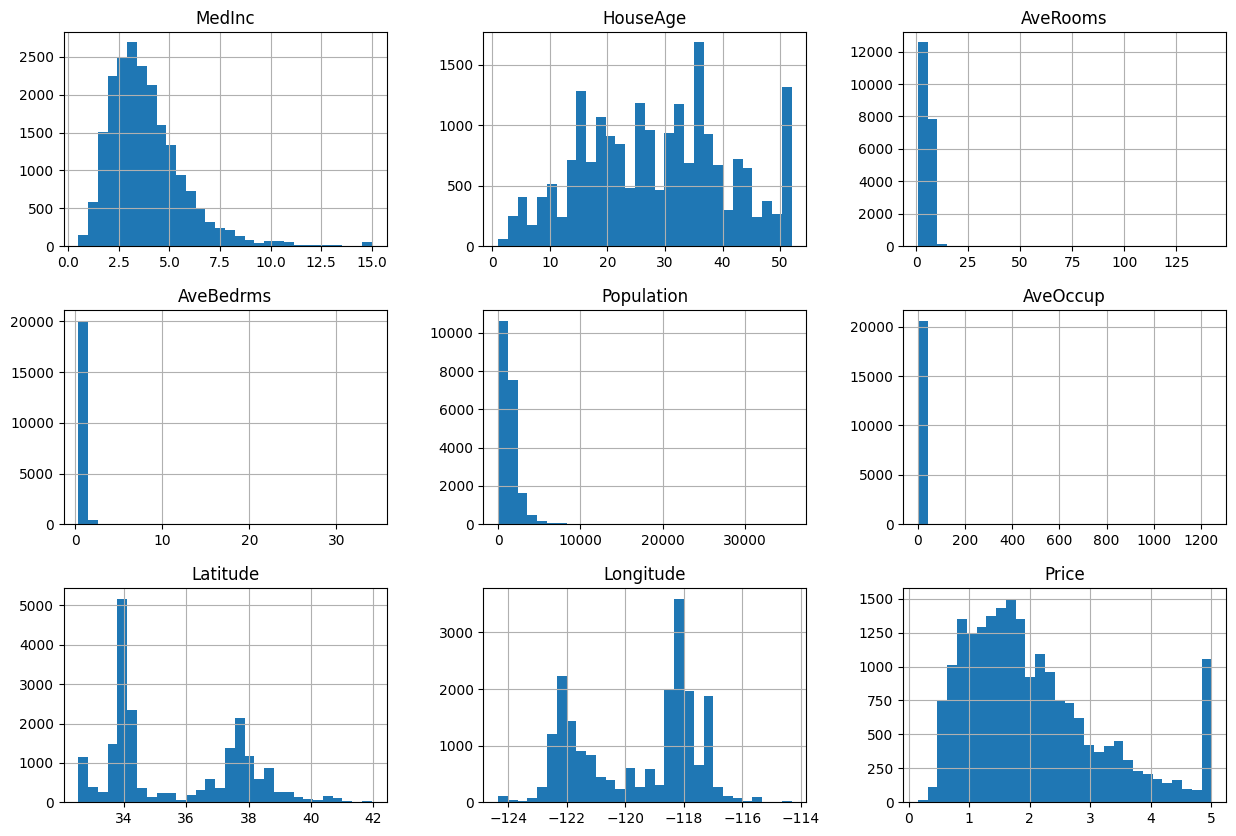

In [ ]:
#HISTOGRAM :show skewed distribution , outliers, range of values 
dataset.hist(figsize=(15,10),bins=30)
plt.show()

              MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
MedInc      1.000000 -0.119034  0.326895  -0.062040    0.004834  0.018766   
HouseAge   -0.119034  1.000000 -0.153277  -0.077747   -0.296244  0.013191   
AveRooms    0.326895 -0.153277  1.000000   0.847621   -0.072213 -0.004852   
AveBedrms  -0.062040 -0.077747  0.847621   1.000000   -0.066197 -0.006181   
Population  0.004834 -0.296244 -0.072213  -0.066197    1.000000  0.069863   
AveOccup    0.018766  0.013191 -0.004852  -0.006181    0.069863  1.000000   
Latitude   -0.079809  0.011173  0.106389   0.069721   -0.108785  0.002366   
Longitude  -0.015176 -0.108197 -0.027540   0.013344    0.099773  0.002476   
Price       0.688075  0.105623  0.151948  -0.046701   -0.024650 -0.023737   

            Latitude  Longitude     Price  
MedInc     -0.079809  -0.015176  0.688075  
HouseAge    0.011173  -0.108197  0.105623  
AveRooms    0.106389  -0.027540  0.151948  
AveBedrms   0.069721   0.013344 -0.046701  
Populatio

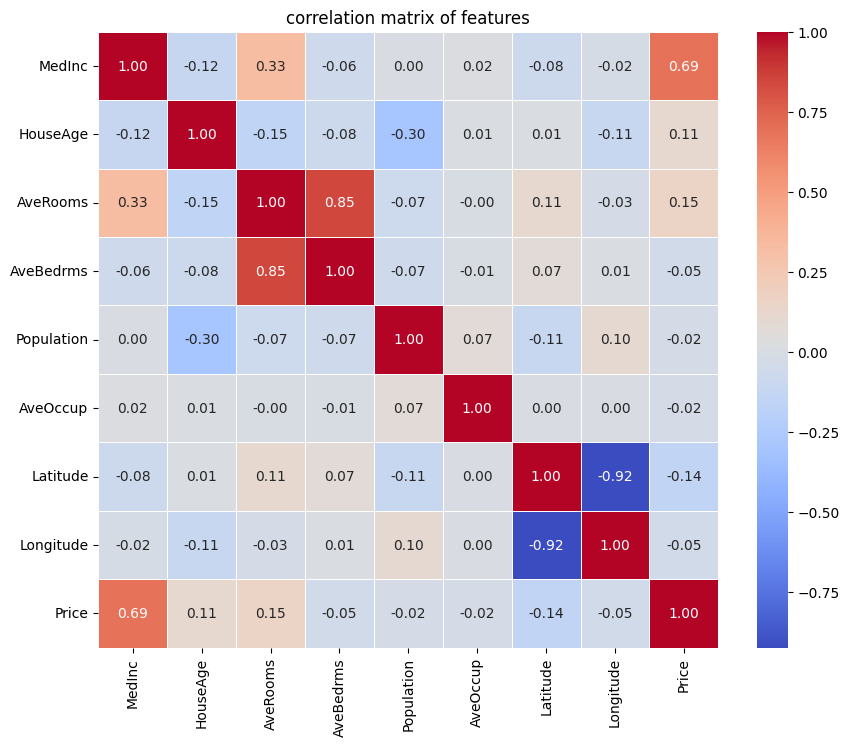

In [ ]:
#correlation heatmap  show whick feature affects price the most which are highly correlated 
corr_matrix=dataset.corr(numeric_only=True) # this will work as it drops columns have non numeric data
print(corr_matrix)
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('correlation matrix of features')
plt.show()

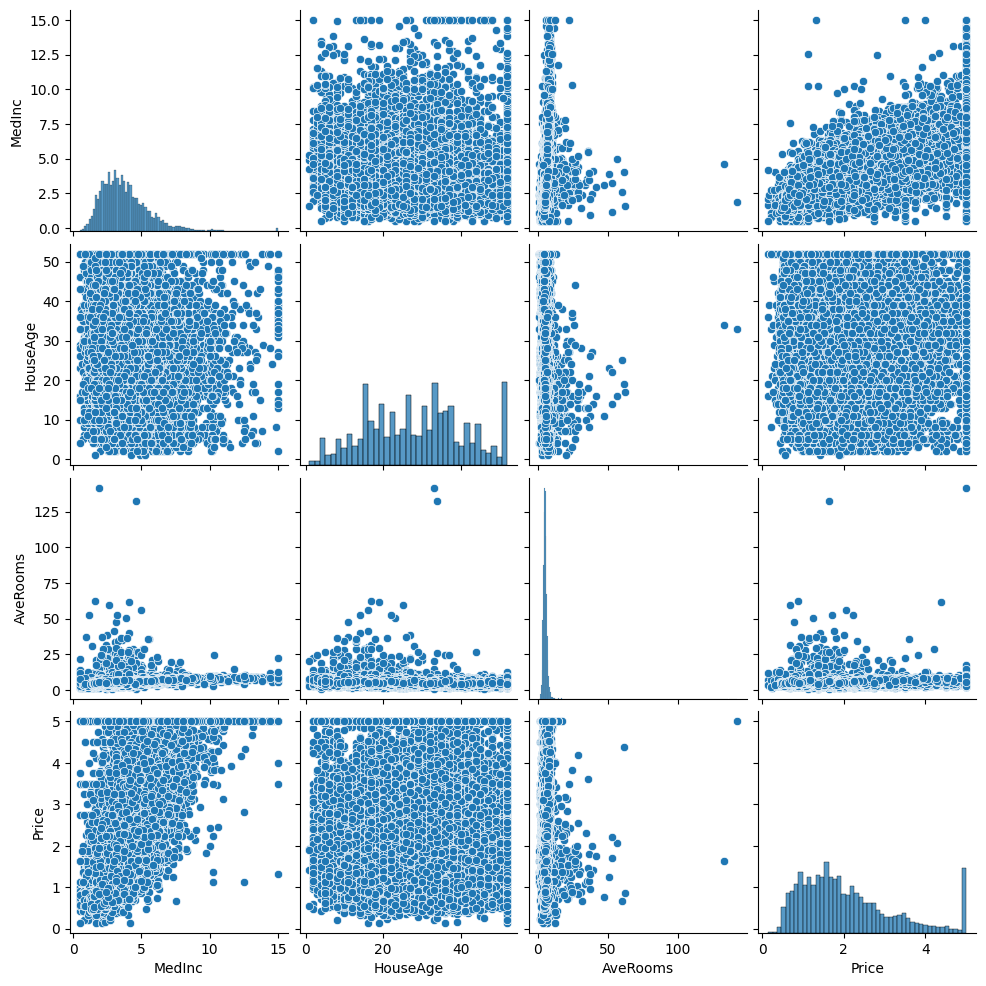

In [ ]:
#pairplot: helps to see relationships between variables .
sns.pairplot(dataset[['MedInc','HouseAge','AveRooms','Price']])
plt.show()

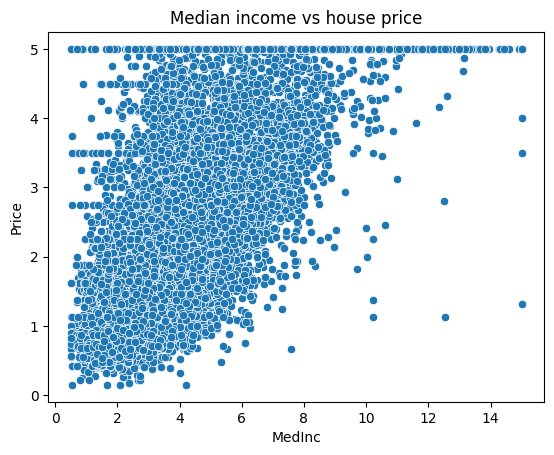

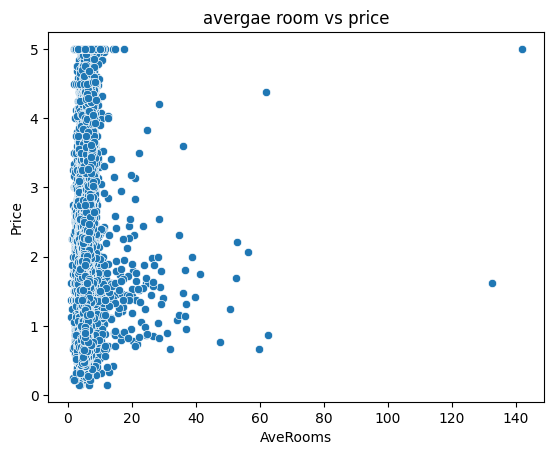

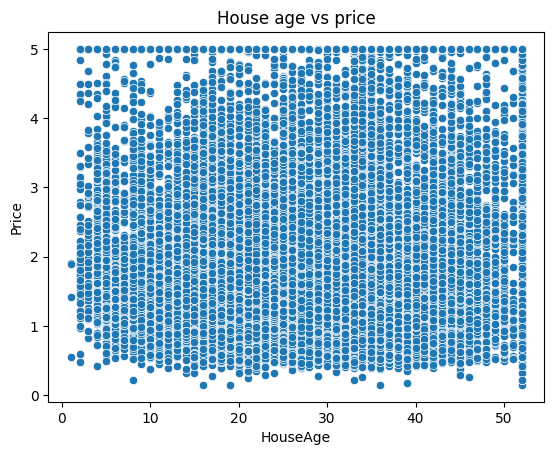

In [21]:
#scatterplot(best for linear regression)
sns.scatterplot(x='MedInc',y='Price',data=dataset)
plt.title("Median income vs house price")
plt.show()
sns.scatterplot(x='AveRooms',y='Price',data=dataset)
plt.title("avergae room vs price")
plt.show()
sns.scatterplot(x='HouseAge',y='Price',data=dataset)
plt.title("House age vs price")
plt.show()

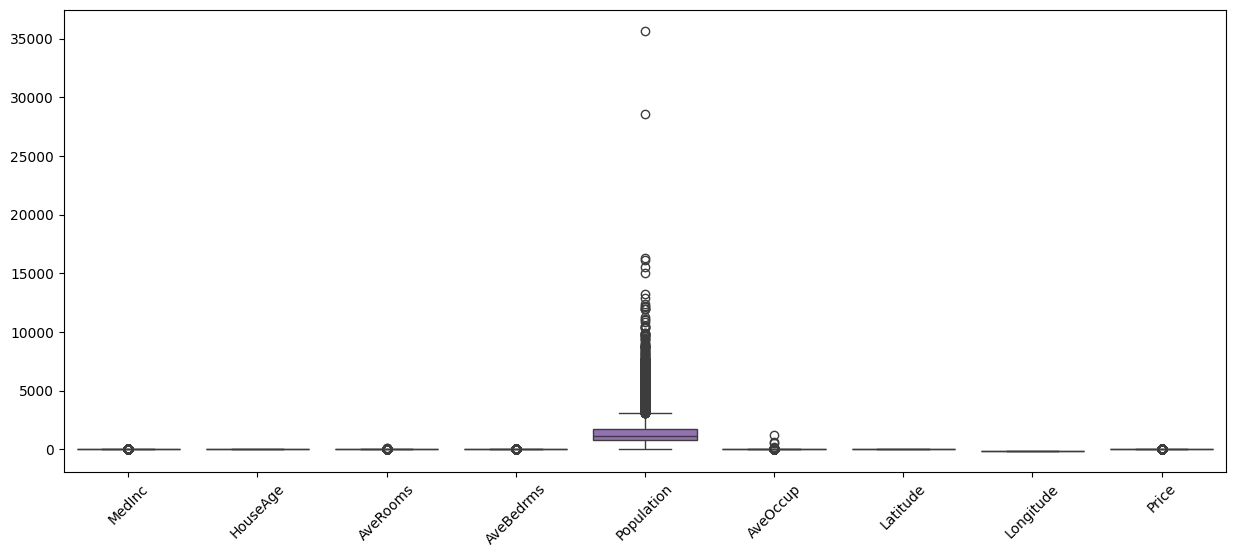

In [ ]:
#box plot :shows outliers in every features
plt.figure(figsize=(15,6))
sns.boxplot(data=dataset)
plt.xticks(rotation=45)
plt.show()

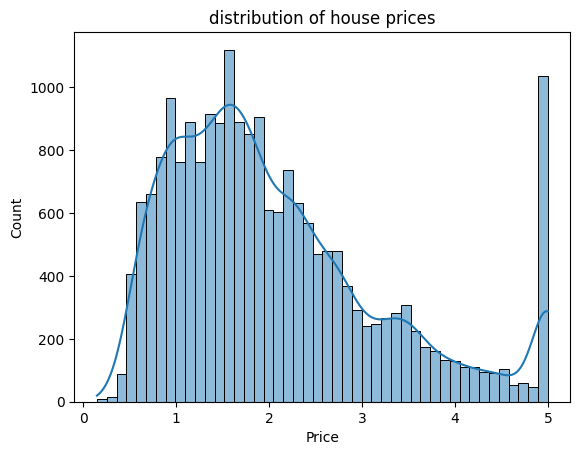

In [25]:
# distribution plot kde curve shows shape of the distribution 
sns.histplot(dataset["Price"],kde=True)
plt.title("distribution of house prices")
plt.show()

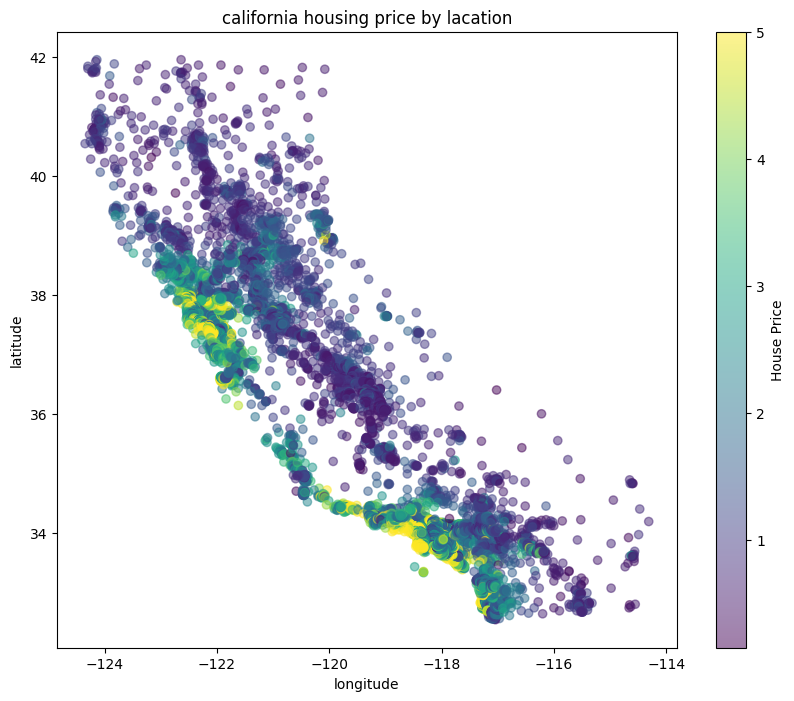

In [ ]:
#Geographical plot: visuizes how house price vary across california 
plt.figure(figsize=(10,8))
plt.scatter(
    dataset['Longitude'],
    dataset['Latitude'],
    c=dataset["Price"],
    cmap="viridis",
    alpha=0.5
)
plt.colorbar(label="House Price")
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.title("california housing price by lacation")
plt.show()

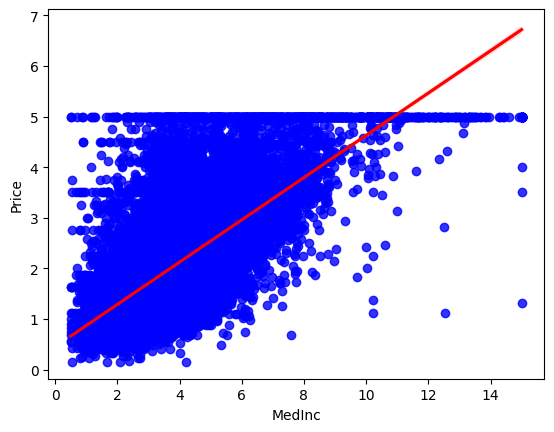

In [31]:
# regression plt : it draws the best fit line especially use for linear regression
sns.regplot(x="MedInc",y="Price",data=dataset,scatter_kws={"color":"blue"},line_kws={"color":"red"})
plt.show()

In [30]:
#count of correnlation this ranks which features are most related to house price 
corr=dataset.corr()["Price"].sort_values(ascending=False)
print(corr)

Price         1.000000
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: Price, dtype: float64


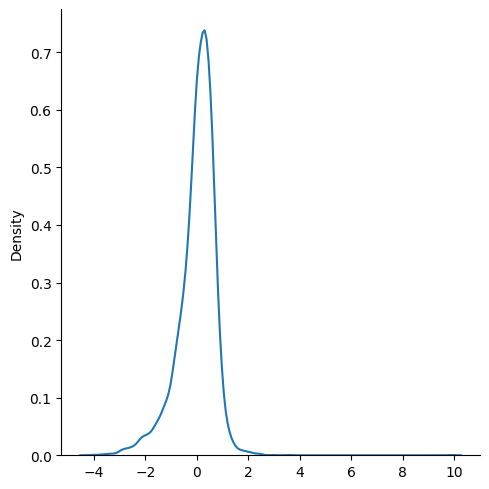

In [ ]:
import seaborn as sns 
sns.displot(reg_pred-y_test,kind='kde')